# 频谱感知：5G NR、4G LTE、WLAN频谱识别

## 实践任务  
对频谱图中的频谱进行分类识别对应的频谱是属于5G NR、4G LTE还是WLAN，并对应进行频谱分割，确定对应的不同信号频谱在图片上的位置。


## 数据集介绍
本次案例改编自Matlab案例Spectrum Sensing with Deep Learning to Identify 5G, LTE, and WLAN Signals。https://www.mathworks.com/help/comm/ug/spectrum-sensing-with-deep-learning-to-identify-5g-and-lte-signals.html  
采用该案例相同的数据集，下载网址：   https://www.mathworks.com/supportfiles/spc/SpectrumSensing/SpectrumSensingTrainingData256x256_2025.zip   
https://www.mathworks.com/supportfiles/spc/SpectrumSensing/SpectrumSensingCapturedData256x256_2025.zip  
数据集主要包括不同的时刻、不同信号的频谱图256x256大小，对应的.png为图片格式的频谱图，对应的.hdf文件为图片上每个像素的标签。  

**STEP 0. 环境配置**  
导入第三方库、设置随机种子、选择设备（CPU/GPU）

In [2]:
import os, glob, random
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

from PIL import Image
import h5py, scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.io import loadmat

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image as _PILImage
from matplotlib.colors import ListedColormap, BoundaryNorm
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" 使用设备: {device}")

 使用设备: cuda


## 认识频谱是怎么产生的  
其中5g_waveform.mat里面的变量waveform是时域的信号

d:\learn\作业存档\python\综合项目实践\人工智能\.venv\lib\site-packages\scipy\io\matlab\_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Waveform data is 2D with shape (153600, 1). Using first column.


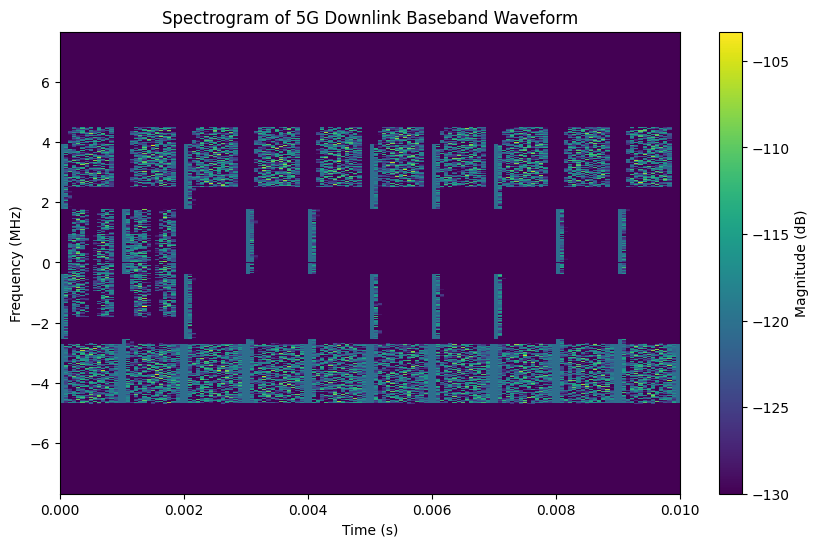

In [3]:
from scipy import signal



# Load the .mat file
mat = loadmat('D:\learn\作业存档\python\综合项目实践\人工智能/5g_waveform.mat')

# The keys in the .mat file might not always be what we expect.
# We've updated the keys based on the error message you received.
# The script now uses 'waveform', 'samplerate', and 'nfft'.
try:
    waveform_data = mat['waveform']
    fs = mat['samplerate'][0, 0]
    nfft = mat['nfft'][0, 0]
except KeyError as e:
    print(f"Error: Could not find key {e} in the .mat file.")
    print(f"Available keys are: {list(mat.keys())}")
    exit()

# Ensure waveform is a 1D array, taking the first column if it's 2D, like MATLAB's waveform(:,1)
if waveform_data.ndim > 1:
    print(f"Waveform data is 2D with shape {waveform_data.shape}. Using first column.")
    waveform = waveform_data[:, 0]
else:
    waveform = waveform_data.flatten()

# Convert to standard integer types to avoid overflow issues
nfft = int(nfft)
fs = int(fs)

# Calculate the spectrogram
# Using parameters similar to the MATLAB command
f, t, Sxx = signal.spectrogram(
    waveform,
    fs=fs,
    window='boxcar',  # rectangular window
    nperseg=nfft,
    noverlap=0,
    nfft=nfft,
    return_onesided=False, # for a centered spectrum
    scaling='spectrum' # returns magnitude
)

# Shift the frequency axis to be centered at zero
f_shifted = np.fft.fftshift(f)
Sxx_shifted = np.fft.fftshift(Sxx, axes=0)

# Convert magnitude to dB (20*log10) and apply threshold
epsilon = 1e-12
# Use 20*log10 for magnitude, 10*log10 for power
Sxx_db = 20 * np.log10(np.abs(Sxx_shifted) + epsilon)
Sxx_db_thresholded = np.clip(Sxx_db, -130, np.max(Sxx_db))


# Plot the spectrogram
plt.figure(figsize=(10, 6))
# Removed shading='gouraud' to get a blockier, more MATLAB-like plot
plt.pcolormesh(t, f_shifted / 1e6, Sxx_db_thresholded, vmin=-130, cmap='viridis')
plt.title('Spectrogram of 5G Downlink Baseband Waveform')
plt.ylabel('Frequency (MHz)')
plt.xlabel('Time (s)')
cbar = plt.colorbar()
cbar.set_label('Magnitude (dB)')
plt.show()

**STEP 0: 数据解压**  
准备数据，因为所有的数据以zip形式上传，所以需要对zip数据进行解压  
首先查看是否有训练数据

In [ ]:
folder_path = '/data/workspace/myshixun'
files = os.listdir(folder_path) 
print(files)


<span style="color:red; font-weight:bold">如果存在文件夹'TrainingData'则不需要解压</span>

In [ ]:
import zipfile
import os
import shutil 
zip_path = '/data/bigfiles/TrainingData.zip'
extract_to = '/data/workspace/myshixun/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)



**查看文件夹的所有文件'/data/workspace/myshixun/TrainingData'**   
其中/data/workspace/myshixun/TrainingData/256x256中有LTE、WLAN、5G NR对应单独的频谱数据，两个文件夹captured、LTE_NR_WLAN文件夹

In [ ]:
folder_path ='/data/workspace/myshixun/TrainingData/256x256'
files = os.listdir(folder_path) 
print(files)

In [ ]:
folder_path = '/data/workspace/myshixun/TrainingData'

for root, dirs, files in os.walk(folder_path):
    print(f'当前目录: {root}')
    for d in dirs:
        print(f'  子目录: {d}')
    for f in files:
        print(f'  文件: {f}')

**STEP 0: 数据读取**  1、读出频谱标签；2、将 {0,63,127,191,255} 映射为 {0,4}。  
<span style="color:red; font-weight:bold">任务一：</span>从 **.mat文件** 导入对应的.mat文件，取出其中的'cdata'变量数据作为输出

In [4]:
# --------------------
# 标签读取  
# --------------------
def load_label(path, prefer_keys='cdata'):
    # 从.mat读标签
    #path 是文件路径,如/data/workspace/myshixun/TrainingData/256x256/LTE_frame_0.mat
   #====================================================
#给出代码
    mat_data = sio.loadmat(path)

    # 去掉 MATLAB 自动生成的无用字段
    valid_keys = [k for k in mat_data.keys() if not k.startswith('__')]

    # 优先使用指定 key
    if prefer_keys in mat_data:
        lbl = mat_data[prefer_keys]
    else:
        # 如果没有该 key，就取第一个有效字段
        if len(valid_keys) == 0:
            raise ValueError("No valid data found in .mat file")
        lbl = mat_data[valid_keys[0]]

    # 转为 numpy 数组（一般本身就是，但保险处理）
    lbl_np = np.array(lbl)

#======================================
    return lbl_np




<span style="color:red; font-weight:bold">任务二：</span>为了便于后续的分类，请构建函数map_label，将标签值与lbl_np从 {0, 63, 127, 191, 255} 统一映射为 {0,1,2,3,4}意义对应，要求输出lbl

In [5]:
import numpy as np

def map_label(lbl_np: np.ndarray) -> np.ndarray:
    """将标签值从 {0, 63, 127, 191, 255} 映射为 {0,1,2,3,4}"""

    # 创建映射字典
    mapping = {
        0: 0,
        63: 1,
        127: 2,
        191: 3,
        255: 4
    }

    # 先创建一个同形状数组
    lbl = np.zeros_like(lbl_np, dtype=np.int64)

    # 逐值映射
    for k, v in mapping.items():
        lbl[lbl_np == k] = v

    return lbl

<span style="color:red; font-weight:bold">任务三：</span>绘制频谱和标签，进行查看如以下形式  
**hint：** 使用前面定义的load_label函数导入标签，并用plt函数绘制，频谱图利用.png格式文件，mpimg.imread，plt.imgshow

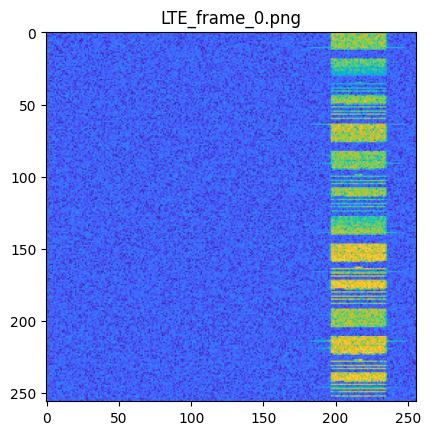  
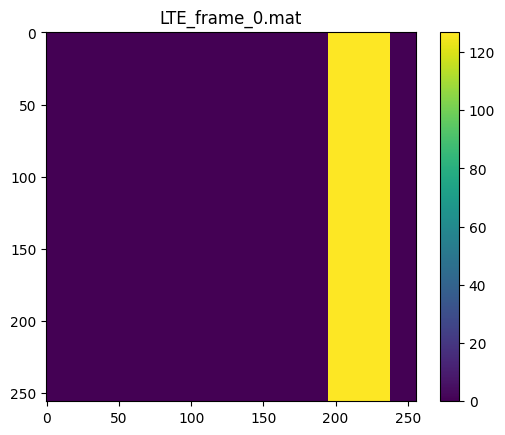

In [ ]:
  #====================================================
#给出代码


#======================================

# Step1: 配置参数
配置数据根目录、子目录、统一尺寸、batch 大小、训练轮数、学习率，类别名。

In [7]:
# --------------------
# 基本配置
# --------------------
                   # 训练/验证/测试统一的尺寸
BATCH_SIZE  = 8                                 # 训练/验证 batch 大小
NUM_EPOCHS  = 20                                # 训练轮数
LR          = 2e-4                              # 学习率（Learning Rate）



CLASS_NAMES = ["Noise", "NR", "LTE", "WLAN", "Unknown"]  # 五种类别，内部编码：0.1.2.3.4
NUM_CLASSES = len(CLASS_NAMES)


In [8]:
DATA_ROOT = r"D:\learn\作业存档\python\综合项目实践\人工智能\TrainingData\TrainingData\256x256"
saving_root=r"D:\learn\作业存档\python\综合项目实践\人工智能saving" #训练的模型存在该目录下面
SUBFOLDERS = [ "captured"]                      # 训练数据在这个子目录下
TARGET_SIZE = (256, 256)   
# 拼接完整路径


# 创建文件夹（如果不存在）
if not os.path.exists(saving_root):
    os.makedirs(saving_root)
    print(f"已创建文件夹：{saving_root}")
else:
    print(f"文件夹已存在：{saving_root}")


已创建文件夹：D:\learn\作业存档\python\综合项目实践\人工智能saving


# Step 2: 数据收集与配对
扫描子目录，按同名文件将 .png 与 .hdf 一一配对

In [9]:
# --------------------
# 数据收集（按文件名配对）
# --------------------
img_paths, lbl_paths = [], []
for sub in SUBFOLDERS:
    folder = os.path.join(DATA_ROOT, sub)
    img_paths.extend(glob.glob(os.path.join(folder, "*.png")))#图像
    lbl_paths.extend(glob.glob(os.path.join(folder, "*.mat")))#标签
# stem（不含扩展名的文件名）相同的 PNG/HDF 组成一对
img_map = {Path(p).stem: p for p in img_paths}
lbl_map = {Path(p).stem: p for p in lbl_paths}
common  = sorted(set(img_map) & set(lbl_map))   #共同的文件名
image_files = [img_map[s] for s in common]
label_files = [lbl_map[s] for s in common]
print(f" {SUBFOLDERS[0]}文件夹中找到 {len(image_files)} 张图像, {len(label_files)} 个标签文件")
print("image_files: ",image_files[0])#image_files是png文件的路径
print("label_files: ",label_files[0])#label_files是mat文件的路径

 captured文件夹中找到 738 张图像, 738 个标签文件
image_files:  D:\learn\作业存档\python\综合项目实践\人工智能\TrainingData\TrainingData\256x256\captured\Band2.4GHz_BW60MHz__frame_0.png
label_files:  D:\learn\作业存档\python\综合项目实践\人工智能\TrainingData\TrainingData\256x256\captured\Band2.4GHz_BW60MHz__frame_0.mat


In [10]:
img_paths, lbl_paths = [], []
LTE_NR_WLAN=["LTE_NR_WLAN"]
for sub in LTE_NR_WLAN:
    folder = os.path.join(DATA_ROOT, sub)
    img_paths.extend(glob.glob(os.path.join(folder, "*.png")))#图像
    lbl_paths.extend(glob.glob(os.path.join(folder, "*.mat")))#标签
# stem（不含扩展名的文件名）相同的 PNG/HDF 组成一对
img_map = {Path(p).stem: p for p in img_paths}
lbl_map = {Path(p).stem: p for p in lbl_paths}
common  = sorted(set(img_map) & set(lbl_map))   #共同的文件名
image_files_c = [img_map[s] for s in common]
label_files_c = [lbl_map[s] for s in common]
print(f" {LTE_NR_WLAN[0]}文件夹中找到 {len(image_files_c)} 张图像, {len(label_files_c)} 个标签文件")


 LTE_NR_WLAN文件夹中找到 2294 张图像, 2294 个标签文件


# Step 3: 类像素频次统计
对所有标签做 map_label 后统计不同类的像素数，并打印频率表

<span style="color:red; font-weight:bold">任务四：</span>统计频谱图中的不同类型的像素点
对label_files中不同频谱图的像素label进行统计

In [12]:
# --------------------
# 像素频次统计（使用 map_label 一致映射）
# --------------------
pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
#=======================================================
#填写代码
import os

for fname in os.listdir(DATA_ROOT):
    if not fname.endswith('.mat'):
        continue

    path = os.path.join(DATA_ROOT, fname)

    # 读取标签
    lbl_np = load_label(path)

    # 映射到 0~4
    lbl = map_label(lbl_np)

    # 展平后统计每个类别数量
    counts = np.bincount(lbl.flatten(), minlength=NUM_CLASSES)

    # 累加
    pixel_counts += counts

#==========================================================
freq = pixel_counts / max(1, pixel_counts.sum())
print("\n=== 标签像素统计结果 ===")
print(pd.DataFrame({"Name":CLASS_NAMES, "PixelCount":pixel_counts, "Frequency":freq}))




=== 标签像素统计结果 ===
      Name  PixelCount  Frequency
0    Noise   115089431   0.650417
1       NR    26490368   0.149708
2      LTE    12229632   0.069115
3     WLAN    23137769   0.130761
4  Unknown           0   0.000000


# Step 4: 数据划分
按比例划分索引并生成三组路径列表

In [13]:
# --------------------
# 数据划分（训练/验证/测试=80/10/10）
# --------------------
def partition_dataset(imgs, lbls, split=(80,10,10), seed=SEED):
    assert len(imgs)==len(lbls)
    n = len(imgs); idx = list(range(n))
    random.Random(seed).shuffle(idx)
    n_tr = int(split[0]/100*n); n_val = int(split[1]/100*n)
    s_tr = idx[:n_tr]; s_val = idx[n_tr:n_tr+n_val]; s_te = idx[n_tr+n_val:]
    pick = lambda arr, ids: [arr[i] for i in ids]
    return pick(imgs,s_tr), pick(lbls,s_tr), pick(imgs,s_val), pick(lbls,s_val), pick(imgs,s_te), pick(lbls,s_te)

imdsTrain, pxdsTrain, imdsVal, pxdsVal, imdsTest, pxdsTest = partition_dataset(image_files, label_files)
print(f" 数据划分完成：Train={len(imdsTrain)}, Val={len(imdsVal)}, Test={len(imdsTest)}")

 数据划分完成：Train=590, Val=73, Test=75


# Step 5: 数据预处理
定义数据集类（图像双线性缩放、归一化到[0,1]；标签最近邻缩放到统一尺寸），并构造三个 DataLoader

In [14]:
# --------------------
# Dataset（统一到 256×256）
# --------------------
class SpectrumDataset(Dataset):
    def __init__(self, imgs, lbls, size=TARGET_SIZE):
        self.imgs, self.lbls, self.size = imgs, lbls, size
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert("RGB").resize(self.size, Image.BILINEAR)
        img = np.asarray(img, dtype=np.float32) / 255.0
        img = np.transpose(img, (2,0,1))  # CHW
        img = torch.from_numpy(img)       # float32

        lbl = load_label(self.lbls[idx])
        lbl = map_label(lbl)              # 一致映射
        if lbl.shape != self.size:
            lbl = Image.fromarray(lbl.astype(np.int32), mode="I").resize(self.size, Image.NEAREST)
            lbl = np.asarray(lbl, dtype=np.int64)
        lbl = torch.from_numpy(lbl)       # long
        return img, lbl

cdsTrain = SpectrumDataset(imdsTrain, pxdsTrain)
cdsVal   = SpectrumDataset(imdsVal,   pxdsVal)
cdsTest  = SpectrumDataset(imdsTest,  pxdsTest)

train_loader = DataLoader(cdsTrain, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(device.type=="cuda"), drop_last=True)
val_loader   = DataLoader(cdsVal,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(cdsTest,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))

imgs_dbg, lbls_dbg = next(iter(train_loader))#快速获取 一个 batch 数据
print(f" 一个批次的图像形状: {imgs_dbg.shape}, 标签形状: {lbls_dbg.shape}")


 一个批次的图像形状: torch.Size([8, 3, 256, 256]), 标签形状: torch.Size([8, 256, 256])


# Step 6a: 模型搭建
搭建四层下采样/上采样的分割网络，输出通道数=类别数，前向包含 softmax。

In [15]:
# --------------------
# 模型：结构（前向含 softmax）
# --------------------
class SpectrumSegNet(nn.Module):
    def __init__(self, num_classes=5, input_channels=3):
        super().__init__()
        # 4 个“卷积+ReLU+2x池化”的下采样块
        self.down1 = nn.Sequential(nn.Conv2d(input_channels,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.down2 = nn.Sequential(nn.Conv2d(128,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
      
        # 4 个“反卷积 + ReLU”上采样块（步幅=2，kernel=4，padding=1）
        self.up1   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
        self.up2   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
     
        # 最后一层 1x1 卷积，把通道数降到 “类别数”
        self.classifier = nn.Conv2d(128, num_classes, 1)
    def forward(self, x):
        x = self.down1(x); x = self.down2(x)
        x = self.up1(x);   x = self.up2(x)
        x = self.classifier(x)
        x = F.softmax(x, dim=1)  # 配合 NLL + FocalNLL
        return x

model = SpectrumSegNet(num_classes=NUM_CLASSES, input_channels=3).to(device)
print("网络结构已创建")
print(model)

网络结构已创建
SpectrumSegNet(
  (down1): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (up1): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (up2): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (classifier): Conv2d(128, 5, kernel_size=(1, 1), stride=(1, 1))
)


# Step 6b: 定义损失函数

In [16]:
# --------------------
# Focal NLLLoss（与 softmax 概率兼容）
# --------------------
class FocalNLLLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, eps=1e-8):
        super().__init__()
        self.gamma, self.weight, self.eps = gamma, weight, eps
    def forward(self, log_probs, target):        # log_probs: [B,C,H,W]（log p）
        probs = torch.exp(log_probs)             # p
        # 取目标类概率 p_t
        B, C, H, W = probs.shape #B: 批量大小（Batch Size）。
                                #C: 类别数（Channels）。
                                #H: 图像的高度（Height）。
                                #W: 图像的宽度（Width）。
        p = probs.permute(0,2,3,1).reshape(-1, C)         # [N,C]，其中 N 是每个批次中所有像素点的总数（即 B * H * W）
        t = target.reshape(-1)                             # [N]
        p_t = p.gather(1, t.unsqueeze(1)).squeeze(1)      # [N]
        focal = (1.0 - p_t) ** self.gamma                 # [N]
        nll   = -log_probs.permute(0,2,3,1).reshape(-1, C).gather(1, t.unsqueeze(1)).squeeze(1)
        loss  = focal * nll
        if self.weight is not None:
            w = self.weight[t]
            loss = loss * w
        return loss.mean()

criterion = FocalNLLLoss(gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Step 7: 训练与验证循环
进行训练
prob=softmax(model(imgs)) → logp → loss.backward()；验证：同但 no_grad；打印 TrainLoss/ValLoss。

In [17]:
from tqdm import tqdm


for epoch in range(1, NUM_EPOCHS + 1):
    # --------------------
    # Train
    # --------------------
    model.train()
    tr_loss = 0.0
    train_loader = DataLoader(cdsTrain, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    train_bar = tqdm(train_loader, desc=f"[Epoch {epoch}/{NUM_EPOCHS}] Training", leave=True)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        prob = model(imgs)# BxCxHxW
                                #B: 批量大小（Batch Size）。
                                #C: 类别数（Channels）。
                                #H: 图像的高度（Height）。
                                #W: 图像的宽度（Width）。
        logp = torch.log(prob.clamp(min=1e-8))
        loss = criterion(logp, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    tr_loss /= max(1, len(cdsTrain) // BATCH_SIZE)

    # --------------------
    # Validation
    # --------------------
    model.eval()
    val_loss = 0.0
    val_loader = DataLoader(cdsVal, batch_size=BATCH_SIZE, shuffle=False)

    val_bar = tqdm(val_loader, desc=f"[Epoch {epoch}/{NUM_EPOCHS}] Validation", leave=True)
    with torch.no_grad():#不进行梯度下降对validation数据进行loss计算
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            prob = model(imgs)
            logp = torch.log(prob.clamp(min=1e-8))
            loss = criterion(logp, labels)
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())

    val_loss /= max(1, len(cdsVal) // BATCH_SIZE)

    # 输出训练loss的结果
    #print(f"\n Epoch {epoch}/{NUM_EPOCHS} — TrainLoss: {tr_loss:.6f} | ValLoss: {val_loss:.6f}\n")

# --------------------
# 保存模型
# --------------------
torch.save(model.state_dict(), saving_root+"/trained_unbias_spectrum_segnet_balanced.pth")
print(" 模型已保存：trained_unbias_spectrum_segnet_balanced.pth")

[Epoch 20/20] Validation: 100%|██████████| 10/10 [00:00<00:00, 12.83it/s, loss=0.317]

 模型已保存：trained_unbias_spectrum_segnet_balanced.pth


# Step 8: 测试集评估
model.eval()→ 遍历 test_loader → 汇总 y_true/y_pred。

In [18]:
# --------------------
# 测试集评估 & 混淆矩阵
# --------------------
model.eval()
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for imgs, labels in DataLoader(cdsTest, batch_size=BATCH_SIZE, shuffle=False):
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model(imgs)
        pred = prob.argmax(1)
        y_true_all.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all.extend(pred.cpu().numpy().ravel().tolist())

<span style="color:red; font-weight:bold">任务五：</span>**绘制混淆矩阵**  
**hint：** 使用confusion_matrix、sns.heatmap

Text(70.72222222222221, 0.5, 'True Class')

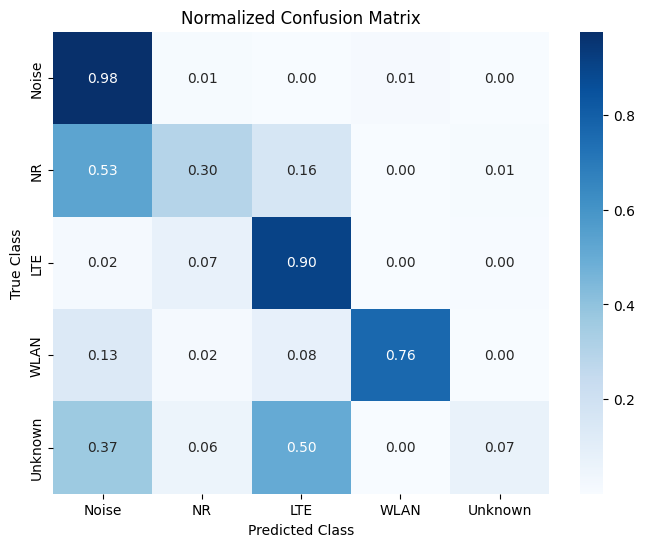

In [ ]:
# ============================================================
#  绘制混淆矩阵（原版单张图）
# ============================================================
  #====================================================
#给出代码
hint = confusion_matrix(y_true_all, y_pred_all)
hint_norm = hint.astype(float) / np.maximum(hint.sum(axis=1, keepdims=True), 1)

#  画图
plt.figure(figsize=(8,6))
sns.heatmap(
    hint_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
#======================================


plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")


<span style="color:red; font-weight:bold">思考题：</span> 思考是什么原因导致训练的出来的混淆矩阵会呈现这个样子？请在下方给出你的分析  
**hint：**  查看数据本身，以及训练的网络结构和criterion的设定

如图所示，频谱类型为NR的预测结果很差，同时unknow信号会被误认为LTE和Noise，根据上面结果，像素比例LTE占比才6%,同时，unkown为0，训练量不足，

导入如预先训练好的模型并对该模型进行验证

In [23]:
# --------------------
# 模型：结构（前向含 softmax）
# --------------------
class SpectrumSegNet_deep(nn.Module):
    def __init__(self, num_classes=5, input_channels=3):
        super().__init__()
        # 4 个“卷积+ReLU+2x池化”的下采样块
        self.down1 = nn.Sequential(nn.Conv2d(input_channels,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.down2 = nn.Sequential(nn.Conv2d(128,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.down3 = nn.Sequential(nn.Conv2d(128,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
        self.down4 = nn.Sequential(nn.Conv2d(128,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2,2))
        # 4 个“反卷积 + ReLU”上采样块（步幅=2，kernel=4，padding=1）
        self.up1   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
        self.up2   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
        self.up3   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
        self.up4   = nn.Sequential(nn.ConvTranspose2d(128,128,4,2,1), nn.ReLU(True))
        # 最后一层 1x1 卷积，把通道数降到 “类别数”
        self.classifier = nn.Conv2d(128, num_classes, 1)
    def forward(self, x):
        x = self.down1(x); x = self.down2(x); x = self.down3(x); x = self.down4(x)
        x = self.up1(x);   x = self.up2(x);   x = self.up3(x);   x = self.up4(x)
        x = self.classifier(x)
        x = F.softmax(x, dim=1)  # 配合 NLL + FocalNLL
        return x

model_pretrained1 = SpectrumSegNet_deep(num_classes=NUM_CLASSES, input_channels=3).to(device)
# 加载权重
model_pretrained1.load_state_dict(torch.load(r"D:\learn\作业存档\python\综合项目实践\人工智能\trained_weight_spectrum_segnet.pth"))

C:\Users\wxm\AppData\Local\Temp\ipykernel_6972\1220224057.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_pretrained1.load_state_dict(torch.load(r"D:\learn\作业存档\p

<All keys matched successfully>

In [24]:

# 设置为评估模式
model_pretrained1.eval()
# --------------------
# 测试集评估 & 混淆矩阵
# --------------------
y_true_all_p1, y_pred_all_p1 = [], []
with torch.no_grad():
    for imgs, labels in DataLoader(cdsTest, batch_size=BATCH_SIZE, shuffle=False):
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model_pretrained1(imgs)
        pred = prob.argmax(1)
        y_true_all_p1.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all_p1.extend(pred.cpu().numpy().ravel().tolist())


**重复**<span style="color:red; font-weight:bold">任务五</span>**绘制混淆矩阵**

Text(70.72222222222221, 0.5, 'True Class')

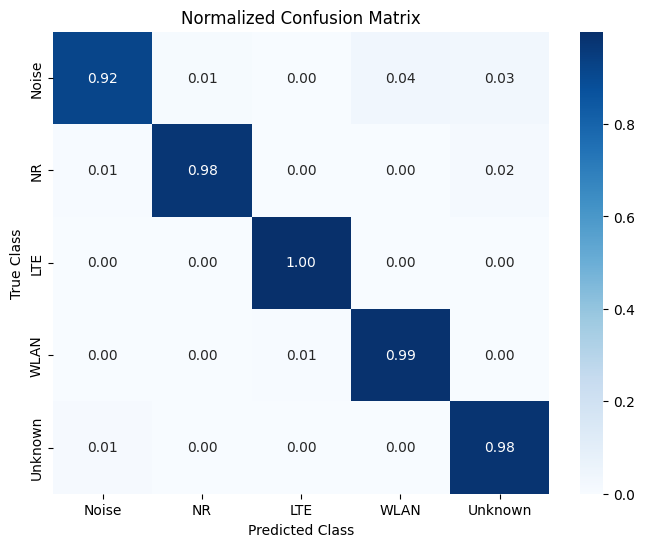

In [ ]:

# ============================================================
#  绘制混淆矩阵（原版单张图）
# ============================================================
  #====================================================
#给出代码
hint = confusion_matrix(y_true_all_p1, y_pred_all_p1)
hint_norm = hint.astype(float) / np.maximum(hint.sum(axis=1, keepdims=True), 1)

# 画图
plt.figure(figsize=(8,6))
sns.heatmap(
    hint_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

#======================================
plt.title("Normalized Confusion Matrix2.0")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

In [28]:
model_pretrained2 = SpectrumSegNet_deep(num_classes=NUM_CLASSES, input_channels=3).to(device)
# 加载权重
model_pretrained2.load_state_dict(torch.load(r"D:\learn\作业存档\python\综合项目实践\人工智能\trained_spectrum_segnet_balanced.pth"))
# 设置为评估模式
model_pretrained2.eval()
# --------------------
# 测试集评估 & 混淆矩阵
# --------------------
y_true_all_p2, y_pred_all_p2 = [], []
with torch.no_grad():
    for imgs, labels in DataLoader(cdsTest, batch_size=BATCH_SIZE, shuffle=False):
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model_pretrained2(imgs)
        pred = prob.argmax(1)
        y_true_all_p2.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all_p2.extend(pred.cpu().numpy().ravel().tolist())


C:\Users\wxm\AppData\Local\Temp\ipykernel_6972\193398019.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_pretrained2.load_state_dict(torch.load(r"D:\learn\作业存档\pyt

**重复**<span style="color:red; font-weight:bold">任务五</span>**绘制混淆矩阵**

Text(70.72222222222221, 0.5, 'True Class')

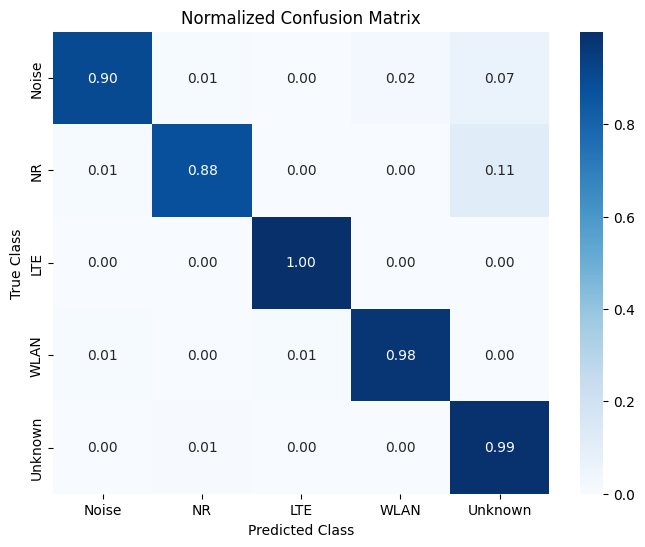

In [29]:
# ============================================================
#  绘制混淆矩阵（原版单张图）
# ============================================================

  #====================================================
#给出代码
hint = confusion_matrix(y_true_all_p2, y_pred_all_p2)
hint_norm = hint.astype(float) / np.maximum(hint.sum(axis=1, keepdims=True), 1)

# 画图
plt.figure(figsize=(8,6))
sns.heatmap(
    hint_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

#======================================
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")


<span style="color:red; font-weight:bold">思考题：</span>分析class FocalNLLLoss中有哪些有心思的设计细节  
**hint：** 从input以及具体的loss计算出发

<span style="color:red; font-weight:bold">任务六：</span>改进criterion,在criterion=FocalNLLLoss()，考虑设置weight变量，构思不同类对应的weight取值，进行重新训练评估  
**hint：** 考虑结合<span style="color:red; font-weight:bold">任务四</span>中不同类像素对应的freq

In [6]:
#==============================================
# --------------------
# 类权重（更强的反频率）,稀有类权重大，大类权重小
# --------------------
  #====================================================
#给出代码
weights = 1.0 / (freq + 1e-6)
weights = weights / weights.sum() * len(weights)

class_weights=torch.tensor(weights, dtype=torch.float32, device=device) #注意class_weight需要时tensor类型
#==============================================
print(" 改进后 Class weights:", weights)
criterion = FocalNLLLoss(gamma=2.0, weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

NameError: name 'freq' is not defined

选用深层网络

In [ ]:
model2 = SpectrumSegNet_deep(num_classes=NUM_CLASSES, input_channels=3).to(device)
print("网络结构已创建")
print(model2)

In [ ]:

for epoch in range(1, NUM_EPOCHS + 1):
    # --------------------
    # Train
    # --------------------
    model2.train()
    tr_loss = 0.0
    train_loader = DataLoader(cdsTrain, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    train_bar = tqdm(train_loader, desc=f"[Epoch {epoch}/{NUM_EPOCHS}] Training", leave=True)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        prob = model2(imgs)# BxCxHxW
                                #B: 批量大小（Batch Size）。
                                #C: 类别数（Channels）。
                                #H: 图像的高度（Height）。
                                #W: 图像的宽度（Width）。
        logp = torch.log(prob.clamp(min=1e-8))
        loss = criterion(logp, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    tr_loss /= max(1, len(cdsTrain) // BATCH_SIZE)

    # --------------------
    # Validation
    # --------------------
    model2.eval()
    val_loss = 0.0
    val_loader = DataLoader(cdsVal, batch_size=BATCH_SIZE, shuffle=False)

    val_bar = tqdm(val_loader, desc=f"[Epoch {epoch}/{NUM_EPOCHS}] Validation", leave=True)
    with torch.no_grad():#不进行梯度下降对validation数据进行loss计算
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            prob = model2(imgs)
            logp = torch.log(prob.clamp(min=1e-8))
            loss = criterion(logp, labels)
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())

    val_loss /= max(1, len(cdsVal) // BATCH_SIZE)

    # 输出训练loss的结果
    #print(f"\n Epoch {epoch}/{NUM_EPOCHS} — TrainLoss: {tr_loss:.6f} | ValLoss: {val_loss:.6f}\n")

# --------------------
# 保存模型
# --------------------
torch.save(model2.state_dict(), saving_root+"/trained_weighted_spectrum_segnet_balanced.pth")
print(" 模型已保存：trained_weighted_spectrum_segnet_balanced.pth")

In [ ]:

# 设置为评估模式
model2.eval()
# --------------------
# 测试集评估 & 混淆矩阵
# --------------------
y_true_all2, y_pred_all2 = [], []
with torch.no_grad():
    for imgs, labels in DataLoader(cdsTest, batch_size=BATCH_SIZE, shuffle=False):
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model2(imgs)
        pred = prob.argmax(1)
        y_true_all2.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all2.extend(pred.cpu().numpy().ravel().tolist())

**重复**<span style="color:red; font-weight:bold">任务五</span>**绘制混淆矩阵**

In [ ]:
# ============================================================
#  绘制混淆矩阵（原版单张图）
# ============================================================
  #====================================================
#给出代码


#======================================

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

**运行下列代码，了解这个训练模型可以实现什么功能**

In [ ]:
CLASS_NAMES = ["Noise", "NR", "LTE", "WLAN", "Unknown"]
PALETTE = np.array([
    [  0, 170, 255],   # Noise  (青蓝)
    [  0, 114, 178],   # NR
    [213,  94,   0],   # LTE
    [  0, 158, 115],   # WLAN
    [204, 121, 167],   # Unknown
], dtype=np.uint8)
PNG_PATH=image_files[0]

LAB_PATH=label_files[0]
TARGET_HW = (256, 256)                   # 训练/推理统一尺寸 (H,W)

# 坐标轴刻度
FREQ_MIN_MHZ, FREQ_MAX_MHZ = -130, 130    # 频率范围（示意）
TIME_MIN_MS,  TIME_MAX_MS  = -40,   0     # 时间范围（示意）
_RESAMPLE_BILINEAR =Image.BILINEAR
print(LAB_PATH)
sampleRate = 61.44e6                                 #Hz
numSubFrames = 40                               # corresponds to 40 ms
frameDuration = numSubFrames*1e-3

In [ ]:
img_pil = Image.open(PNG_PATH).convert("RGB").resize((TARGET_HW[1], TARGET_HW[0]), _RESAMPLE_BILINEAR)
img_np  = np.asarray(img_pil, dtype=np.float32)            # HxWx3
img_chw = np.transpose(img_np/255.0, (2,0,1))              # 归一化到 [0,1]，CHW
img_t   = torch.from_numpy(img_chw).unsqueeze(0).to(device)

# 读 hdf（真实标签）→ 0..4，并用最近邻缩放到训练尺寸
lbl_raw = load_label(LAB_PATH)
lbl_map = map_label(lbl_raw)
if lbl_map.shape != TARGET_HW:
    lbl_map = np.asarray(
        Image.fromarray(lbl_map.astype(np.int32), mode="I").resize((TARGET_HW[1], TARGET_HW[0]), Image.NEAREST),
        dtype=np.int64
    )

# 加载模型权重并推理

model2.eval()
with torch.no_grad():
    prob = model2(img_t)                       # [1,5,H,W]
    pred = prob.argmax(1).squeeze(0).cpu().numpy().astype(np.int64)  # 0..4

# =========================
# 5) 绘图：三行图
# =========================
# 类别 colormap（标签 & 预测用同一套）
cmap = ListedColormap(PALETTE / 255.0)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)

# extent 设置坐标范围（若提供）
#extent = None
if None not in (FREQ_MIN_MHZ, FREQ_MAX_MHZ, TIME_MIN_MS, TIME_MAX_MS):
    extent = [FREQ_MIN_MHZ, FREQ_MAX_MHZ, TIME_MIN_MS, TIME_MAX_MS]
else:
    # 默认像素坐标
    extent = None

fig = plt.figure(figsize=(10, 6))

# (1) Received Spectrogram
ax1 = plt.subplot(3,1,1)
im1 = ax1.imshow(img_np.astype(np.uint8), aspect='auto', extent=extent, origin='upper')
ax1.set_title("Received Spectrogram", fontsize=12, weight='bold')
ax1.set_xlabel("Frequency "); ax1.set_ylabel("Time (ms)")
# 给顶图加一个颜色条（只是示意，并不代表真实功率单位）
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_ticks([]); cbar1.set_label("Power (norm.)")

# (2) True labels
ax2 = plt.subplot(3,1,2)
im2 = ax2.imshow(lbl_map, cmap=cmap, norm=norm, aspect='auto', extent=extent, origin='upper')
ax2.set_title("True signal labels", fontsize=12, weight='bold')
ax2.set_xlabel("Frequency "); ax2.set_ylabel("Time")
# 类别色条（离散刻度）
cbar2 = plt.colorbar(im2, ax=ax2, ticks=np.arange(0,5,1), fraction=0.046, pad=0.04)
cbar2.ax.set_yticklabels(CLASS_NAMES)

# (3) Estimated labels
ax3 = plt.subplot(3,1,3)
im3 = ax3.imshow(pred, cmap=cmap, norm=norm, aspect='auto', extent=extent, origin='upper')
ax3.set_title("Estimated signal labels", fontsize=12, weight='bold')
ax3.set_xlabel("Frequency"); ax3.set_ylabel("Time")
cbar3 = plt.colorbar(im3, ax=ax3, ticks=np.arange(0,5,1), fraction=0.046, pad=0.04)
cbar3.ax.set_yticklabels(CLASS_NAMES)

plt.tight_layout()
plt.show()

In [ ]:
PNG_PATH=image_files_c[0]

LAB_PATH=label_files_c[0]
img_pil = Image.open(PNG_PATH).convert("RGB").resize((TARGET_HW[1], TARGET_HW[0]), _RESAMPLE_BILINEAR)
img_np  = np.asarray(img_pil, dtype=np.float32)            # HxWx3
img_chw = np.transpose(img_np/255.0, (2,0,1))              # 归一化到 [0,1]，CHW
img_t   = torch.from_numpy(img_chw).unsqueeze(0).to(device)

# 读 hdf（真实标签）→ 0..4，并用最近邻缩放到训练尺寸
lbl_raw = load_label(LAB_PATH)
lbl_map = map_label(lbl_raw)
if lbl_map.shape != TARGET_HW:
    lbl_map = np.asarray(
        Image.fromarray(lbl_map.astype(np.int32), mode="I").resize((TARGET_HW[1], TARGET_HW[0]), Image.NEAREST),
        dtype=np.int64
    )

# 加载模型权重并推理

model_pretrained2.eval()
with torch.no_grad():
    prob = model_pretrained2(img_t)                       # [1,5,H,W]
    pred = prob.argmax(1).squeeze(0).cpu().numpy().astype(np.int64)  # 0..4

# =========================
# 5) 绘图：三行图
# =========================
# 类别 colormap（标签 & 预测用同一套）
cmap = ListedColormap(PALETTE / 255.0)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)

# extent 设置坐标范围（若提供）
if None not in (FREQ_MIN_MHZ, FREQ_MAX_MHZ, TIME_MIN_MS, TIME_MAX_MS):
    extent = [FREQ_MIN_MHZ, FREQ_MAX_MHZ, TIME_MIN_MS, TIME_MAX_MS]
else:
    # 默认像素坐标
    extent = None

fig = plt.figure(figsize=(10, 6))

# (1) Received Spectrogram
ax1 = plt.subplot(3,1,1)
im1 = ax1.imshow(img_np.astype(np.uint8), aspect='auto', extent=extent, origin='upper')
ax1.set_title("Received Spectrogram", fontsize=12, weight='bold')
ax1.set_xlabel("Frequency "); ax1.set_ylabel("Time (ms)")
# 给顶图加一个颜色条（只是示意，并不代表真实功率单位）
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_ticks([]); cbar1.set_label("Power (norm.)")

# (2) True labels
ax2 = plt.subplot(3,1,2)
im2 = ax2.imshow(lbl_map, cmap=cmap, norm=norm, aspect='auto', extent=extent, origin='upper')
ax2.set_title("True signal labels", fontsize=12, weight='bold')
ax2.set_xlabel("Frequency "); ax2.set_ylabel("Time (ms)")
# 类别色条（离散刻度）
cbar2 = plt.colorbar(im2, ax=ax2, ticks=np.arange(0,5,1), fraction=0.046, pad=0.04)
cbar2.ax.set_yticklabels(CLASS_NAMES)

# (3) Estimated labels
ax3 = plt.subplot(3,1,3)
im3 = ax3.imshow(pred, cmap=cmap, norm=norm, aspect='auto', extent=extent, origin='upper')
ax3.set_title("Estimated signal labels", fontsize=12, weight='bold')
ax3.set_xlabel("Frequency"); ax3.set_ylabel("Time (ms)")
cbar3 = plt.colorbar(im3, ax=ax3, ticks=np.arange(0,5,1), fraction=0.046, pad=0.04)
cbar3.ax.set_yticklabels(CLASS_NAMES)

plt.tight_layout()
plt.show()

选用 LTE_NR_WLAN 文件夹中的 image_files_c label_files_c进行测试

In [ ]:
# --------------------
# 测试集评估 & 混淆矩阵
# --------------------
# ============================================================
# 测试集改为 LTE_NR_WLAN 文件夹 image_files_c label_files_c
# ============================================================
length = len(image_files_c)
random.seed(SEED) 
# 从 0 到 length-1 中随机选出 20 个不重复的索引
random_indices = random.sample(range(length), 20)

test_imgs = [image_files_c[i] for i in random_indices]
test_lbls = [label_files_c[i] for i in random_indices]
assert len(test_imgs) == len(test_lbls), " PNG/mat 数量不匹配！"
print(f" 新测试集加载完成：{len(test_imgs)} 对样本")

newTest = SpectrumDataset(test_imgs, test_lbls)
test_loader = DataLoader(newTest, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=(device.type=="cuda"))

<span style="color:red; font-weight:bold">任务八：</span>对model_pretrained1、model_pretrained2，在上述test_loader下进行评估推理，参考前面的testing评估推理步骤，并绘制confusion matrix的图

In [ ]:


# ============================================================
# 推理
# ============================================================
model_pretrained1.eval()
y_true_all_t1, y_pred_all_t1 = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model_pretrained1(imgs)
        pred = prob.argmax(1)
        y_true_all_t1.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all_t1.extend(pred.cpu().numpy().ravel().tolist())

model_pretrained2.eval()
y_true_all_t2, y_pred_all_t2 = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        prob = model_pretrained1(imgs)
        pred = prob.argmax(1)
        y_true_all_t2.extend(labels.cpu().numpy().ravel().tolist())
        y_pred_all_t2.extend(pred.cpu().numpy().ravel().tolist())


In [ ]:
# ============================================================
#  绘制混淆矩阵（原版单张图）
# ============================================================
  #====================================================
#给出代码


#======================================


plt.title("model_pretrained1: Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

  #====================================================
#给出代码


#======================================


plt.title("model_pretrained2: Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

<span style="color:red; font-weight:bold">思考题：</span>分析出现上面confusion matrix和之前的频谱分割效果的原因应该如何改进  
**hint：** overfitting

<span style="color:red; font-weight:bold">任务九：</span>给出解决上述问题的思路和代码

<span style="color:red; font-weight:bold">总结：</span>写几句话，从代码编程到频谱感知，这个实践项目给你的启发

# 后面内容为选作提升内容

<span style="color:red; font-weight:bold">任务十：</span>改进class FocalNLLLoss，设计自己的criterion,给出思路和代码

<span style="color:red; font-weight:bold">任务十一：</span>如何提升model网络的训练性能，给出思路和代码
**hint:**  改进criterion、改进网络bias初始化、类权重与偏置先验、改进损失函数

**类权重与偏置先验** 
用像素频次做“反频率”类权重；用（反频率的对数）初始化分类头 bias，缓解大类偏置。

**模型训练**

**模型测试验证并绘制混淆矩阵**